**Nome:** RICARDO FERNANDES DE ALMEIDA<br>
**Turma:** 2025.2<br>
**Especialização Cesar - Engenharia e Análise de DADOS**  
**Disciplina: RNA e Deep Learning**<br>
**Atividade: Atividade Aula 3 - Vale o dobro(Regressão Logística - Student Exam Performance)**

# Student Exam Performance - Regressão Logística - 2 classes

## Objetivo

Este notebook aplica Regressão Logística com PyTorch ao dataset **Student Exam Performance Prediction** (Kaggle).

O objetivo é classificar se um aluno irá **passar (1)** ou **reprovar (0)** em um exame com base em:
- `Study Hours`: horas de estudo
- `Previous Exam Score`: nota na prova anterior

Principais características:
- **Problema:** classificação binária (2 classes: 0 = reprovado, 1 = aprovado)
- **Função de perda:** Entropia Cruzada (CrossEntropyLoss)
- **Arquitetura:** camada linear com 2 entradas e 2 saídas (uma por classe)
- **Referência:** [Kaggle - Student Exam Performance Prediction](https://www.kaggle.com/datasets/mrsimple07/student-exam-performance-prediction)

## Importação das bibliotecas

In [1]:
%matplotlib inline
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

import torch
from torch.autograd import Variable
import torch.nn as nn
import torch.nn.functional as F

## Download do dataset

O arquivo `student_exam_data.csv` pode ser baixado pelo Kaggle CLI manualmente.

**Opção – manual:** Baixe o arquivo em https://www.kaggle.com/datasets/mrsimple07/student-exam-performance-prediction e coloque `student_exam_data.csv` na mesma pasta deste notebook.

In [2]:
CSV_FILE = 'student_exam_data.csv'

if not os.path.exists(CSV_FILE):
    try:
        import kagglehub
        path = kagglehub.dataset_download('mrsimple07/student-exam-performance-prediction')
        # Localiza o CSV dentro do diretório baixado
        for root, dirs, files in os.walk(path):
            for f in files:
                if f.endswith('.csv') and 'exam_data' in f:
                    import shutil
                    shutil.copy(os.path.join(root, f), CSV_FILE)
                    print(f'Arquivo copiado: {f} -> {CSV_FILE}')
                    break
    except Exception as e:
        print(f'Não foi possível baixar automaticamente: {e}')
        print('Por favor, coloque o arquivo student_exam_data.csv nesta pasta manualmente.')
else:
    print(f'Arquivo {CSV_FILE} encontrado localmente.')

Using Colab cache for faster access to the 'student-exam-performance-prediction' dataset.
Arquivo copiado: student_exam_data_new.csv -> student_exam_data.csv


## Dataset: Leitura, normalização e visualização dos dados

In [3]:
df = pd.read_csv(CSV_FILE)
print('Shape:', df.shape)
print('\nPrimeiras linhas:')
df.head()

Shape: (500, 3)

Primeiras linhas:


,Study Hours,Previous Exam Score,Pass/Fail
0,4.370861,81.889703,0
1,9.556429,72.165782,1
2,7.587945,58.571657,0
3,6.387926,88.827701,1
4,2.404168,81.083870,0


In [4]:
print('Colunas:', df.columns.tolist())
print('\nInformações gerais:')
df.info()
print('\nEstatísticas descritivas:')
df.describe()

Colunas: ['Study Hours', 'Previous Exam Score', 'Pass/Fail']

Informações gerais:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 3 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Study Hours          500 non-null    float64
 1   Previous Exam Score  500 non-null    float64
 2   Pass/Fail            500 non-null    int64  
dtypes: float64(2), int64(1)
memory usage: 11.8 KB

Estatísticas descritivas:


,Study Hours,Previous Exam Score,Pass/Fail
count,500.000000,500.000000,500.000000
mean,5.487055,68.917084,0.368000
std,2.688196,17.129607,0.482744
min,1.045554,40.277921,0.000000
25%,3.171517,53.745955,0.000000
50%,5.618474,68.309294,0.000000
75%,7.805124,83.580209,1.000000
max,9.936683,99.983060,1.000000


In [5]:
print('Distribuição da classe (Pass/Fail):')
print(df['Pass/Fail'].value_counts())
print(f'\nAprovados: {(df["Pass/Fail"]==1).sum()} | Reprovados: {(df["Pass/Fail"]==0).sum()}')

Distribuição da classe (Pass/Fail):
Pass/Fail
0    316
1    184
Name: count, dtype: int64

Aprovados: 184 | Reprovados: 316


In [6]:
# Extrai features e target
X = df[['Study Hours', 'Previous Exam Score']].values.astype(np.float32)
Y = df['Pass/Fail'].values.astype(np.int64)

# Normalização min-max para [0, 1]
X_min = X.min(axis=0)
X_range = X.max(axis=0) - X_min
Xn = (X - X_min) / X_range

print('Shape de X normalizado:', Xn.shape)
print('Shape de Y:', Y.shape)
print('Classes únicas:', np.unique(Y))

Shape de X normalizado: (500, 2)
Shape de Y: (500,)
Classes únicas: [0 1]


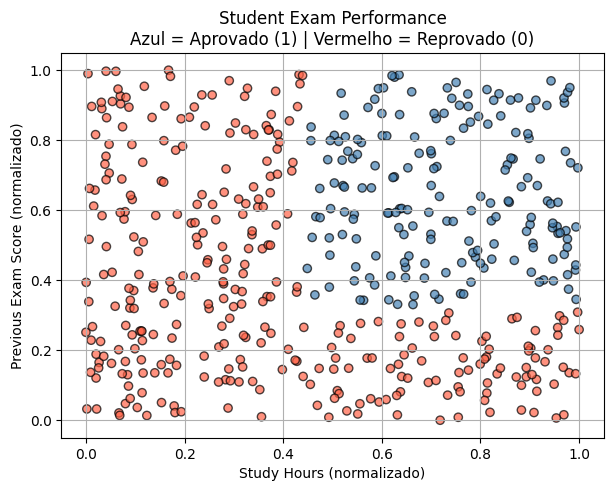

In [7]:
# Visualização dos dados normalizados
colors = np.where(Y == 1, 'steelblue', 'tomato')

plt.figure(figsize=(7, 5))
plt.scatter(Xn[:, 0], Xn[:, 1], c=colors, edgecolors='k', alpha=0.7)
plt.xlabel('Study Hours (normalizado)')
plt.ylabel('Previous Exam Score (normalizado)')
plt.title('Student Exam Performance\nAzul = Aprovado (1) | Vermelho = Reprovado (0)')
plt.grid(True)
plt.show()

### Prepara os dados para o PyTorch

In [8]:
X_tensor = torch.FloatTensor(Xn)   # Entrada é FloatTensor
Y_tensor = torch.LongTensor(Y)     # Classe é LongTensor

print('X_tensor shape:', X_tensor.shape)
print('Y_tensor shape:', Y_tensor.shape)
print('\nPrimeiros valores de Y_tensor:', Y_tensor[:10])

X_tensor shape: torch.Size([500, 2])
Y_tensor shape: torch.Size([500])

Primeiros valores de Y_tensor: tensor([0, 1, 0, 1, 0, 0, 0, 1, 1, 1])


## Construindo o modelo da rede

A saída da rede possui um neurônio para cada classe (0 = reprovado, 1 = aprovado). A saída são os *logits* (scores antes do Softmax):

- **Entradas:** 2 (`Study Hours`, `Previous Exam Score`)
- **Saídas:** 2 (uma para cada classe)

In [9]:
model = nn.Linear(2, 2)  # 2 entradas, 2 saídas (uma por classe)
print('Parâmetros do modelo:')
print(model.state_dict())
print(f'\nTotal de parâmetros: {sum(p.numel() for p in model.parameters())}')
print(f'  - Pesos (weight): {model.weight.numel()}')
print(f'  - Bias:           {model.bias.numel()}')

Parâmetros do modelo:
OrderedDict({'weight': tensor([[-0.6560, -0.0846],
        [ 0.4877,  0.2438]]), 'bias': tensor([0.3316, 0.6640])})

Total de parâmetros: 6
  - Pesos (weight): 4
  - Bias:           2


### Fazendo um predict antes do treinamento

In [10]:
out = model(Variable(X_tensor[:5, :]))  # 5 amostras
print('Logits (scores):')
print(out)

Logits (scores):
tensor([[ 0.0273,  1.0163],
        [-0.3415,  1.2611],
        [-0.1770,  1.0976],
        [-0.1314,  1.1553],
        [ 0.1736,  0.9051]], grad_fn=<AddmmBackward0>)


In [11]:
probs = F.softmax(out, dim=1)
print('Probabilidades (após Softmax):')
print(probs)
print('\nSoma por linha (deve ser 1.0):', probs.sum(dim=1))

Probabilidades (após Softmax):
tensor([[0.2711, 0.7289],
        [0.1676, 0.8324],
        [0.2185, 0.7815],
        [0.2164, 0.7836],
        [0.3248, 0.6752]], grad_fn=<SoftmaxBackward0>)

Soma por linha (deve ser 1.0): tensor([1., 1., 1., 1., 1.], grad_fn=<SumBackward1>)


In [12]:
prob_max, y_pred_initial = torch.max(F.softmax(out, dim=1), dim=1)
print('Classe predita:', y_pred_initial)
print('Probabilidade máxima:', prob_max)

Classe predita: tensor([1, 1, 1, 1, 1])
Probabilidade máxima: tensor([0.7289, 0.8324, 0.7815, 0.7836, 0.6752], grad_fn=<MaxBackward0>)


## Treinamento

### Inicialização dos parâmetros

In [13]:
lr = 0.15
nb_epoch = 5000

# Reinicia o modelo para garantir partida do zero
model = nn.Linear(2, 2)

optimizer = torch.optim.SGD(model.parameters(), lr=lr)
criterion = nn.CrossEntropyLoss()

### Laço principal de treinamento da Regressão Logística por Softmax

In [14]:
losses = []

for i in range(nb_epoch):
    # Forward: predict da rede
    output = model(Variable(X_tensor))

    # Calcula a perda
    loss = criterion(output, Variable(Y_tensor))

    # Backpropagation e atualização dos parâmetros
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    losses.append(loss.item())

    if (i + 1) % 500 == 0:
        print(f'Época [{i+1}/{nb_epoch}] - Loss: {loss.item():.6f}')

print(f'\nLoss final: {losses[-1]:.6f}')

Época [500/5000] - Loss: 0.348307
Época [1000/5000] - Loss: 0.307351
Época [1500/5000] - Loss: 0.291555
Época [2000/5000] - Loss: 0.283545
Época [2500/5000] - Loss: 0.278906
Época [3000/5000] - Loss: 0.275997
Época [3500/5000] - Loss: 0.274076
Época [4000/5000] - Loss: 0.272759
Época [4500/5000] - Loss: 0.271832
Época [5000/5000] - Loss: 0.271164

Loss final: 0.271164


### Gráfico da perda ao longo do treinamento

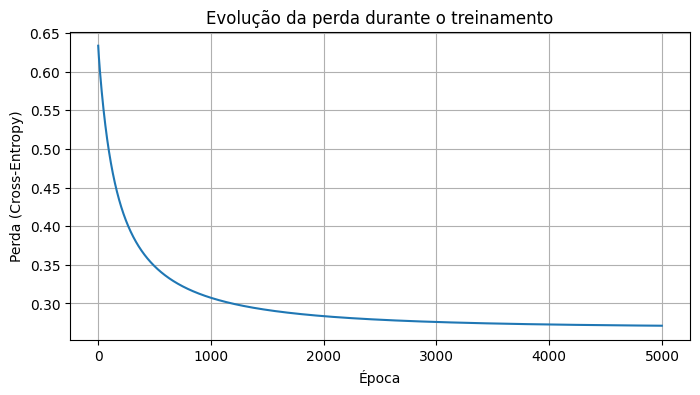

In [15]:
plt.figure(figsize=(8, 4))
plt.plot(losses)
plt.xlabel('Época')
plt.ylabel('Perda (Cross-Entropy)')
plt.title('Evolução da perda durante o treinamento')
plt.grid(True)
plt.show()

### Fronteira de decisão após o treinamento

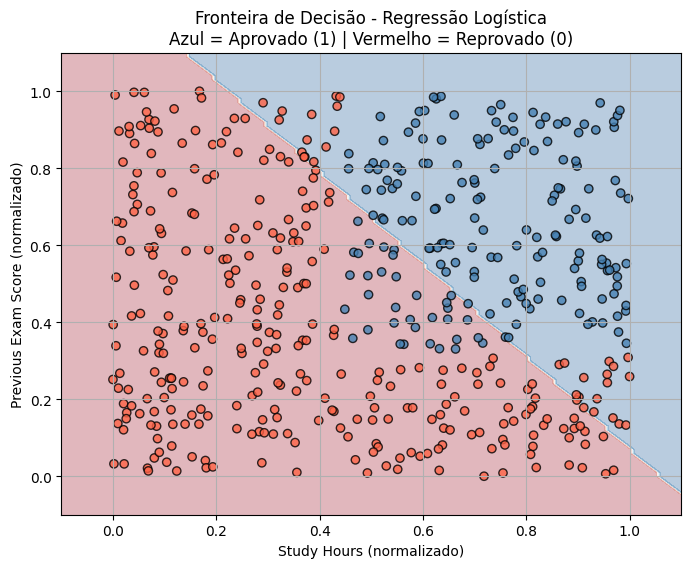

In [16]:
# Cria grid para plotar a fronteira de decisão
h = 0.01
x0_min, x0_max = Xn[:, 0].min() - 0.1, Xn[:, 0].max() + 0.1
x1_min, x1_max = Xn[:, 1].min() - 0.1, Xn[:, 1].max() + 0.1
xx, yy = np.meshgrid(np.arange(x0_min, x0_max, h),
                     np.arange(x1_min, x1_max, h))

grid = torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])
with torch.no_grad():
    Z = torch.max(model(grid), dim=1).indices.numpy()
Z = Z.reshape(xx.shape)

plt.figure(figsize=(8, 6))
plt.contourf(xx, yy, Z, alpha=0.3, cmap='RdBu')
plt.scatter(Xn[:, 0], Xn[:, 1], c=colors, edgecolors='k', alpha=0.8)
plt.xlabel('Study Hours (normalizado)')
plt.ylabel('Previous Exam Score (normalizado)')
plt.title('Fronteira de Decisão - Regressão Logística\nAzul = Aprovado (1) | Vermelho = Reprovado (0)')
plt.grid(True)
plt.show()

## Avaliação

### Parâmetros após o treinamento

In [17]:
print('Pesos e bias treinados:')
print(model.state_dict())

Pesos e bias treinados:
OrderedDict({'weight': tensor([[-4.7539, -3.9688],
        [ 4.1348,  3.4412]]), 'bias': tensor([ 5.0439, -4.3658])})


### Acurácia no conjunto de treinamento

In [18]:
with torch.no_grad():
    outputs = model(X_tensor)
    _, Y_pred = torch.max(outputs, dim=1)

Y_pred_np = Y_pred.numpy()
accuracy = (Y_pred_np == Y).mean()
print(f'Acurácia no treinamento: {accuracy:.4f} ({accuracy*100:.2f}%)')

Acurácia no treinamento: 0.8680 (86.80%)


### Matriz de confusão

In [19]:
print('Matriz de confusão (linhas = predito, colunas = real):')
cm = pd.crosstab(Y_pred_np, Y,
                 rownames=['Predito'],
                 colnames=['Real'])
cm.index = [f'{i} (Reprovado)' if i == 0 else f'{i} (Aprovado)' for i in cm.index]
cm.columns = [f'{c} (Reprovado)' if c == 0 else f'{c} (Aprovado)' for c in cm.columns]
print(cm)

Matriz de confusão (linhas = predito, colunas = real):
               0 (Reprovado)  1 (Aprovado)
0 (Reprovado)            284            34
1 (Aprovado)              32           150


### Salvando os parâmetros treinados

In [20]:
os.makedirs('models', exist_ok=True)
torch.save(model.state_dict(), 'models/RegrLog_StudentExam.pt')
print('Modelo salvo em models/RegrLog_StudentExam.pt')

Modelo salvo em models/RegrLog_StudentExam.pt


In [21]:
import torch

arquivo = "/content/models/RegrLog_StudentExam.pt"

modelo_ou_pesos = torch.load(arquivo, map_location="cpu", weights_only=False)

print(f"{type(modelo_ou_pesos)} {modelo_ou_pesos}")


<class 'collections.OrderedDict'> OrderedDict({'weight': tensor([[-4.7539, -3.9688],
        [ 4.1348,  3.4412]]), 'bias': tensor([ 5.0439, -4.3658])})


## Principais Aprendizados

### Principais Aprendizados

A partir da análise e execução deste notebook, podemos destacar os seguintes pontos:

*   **Regressão Logística com PyTorch:** A implementação de um modelo de Regressão Logística para classificação binária é feita com `nn.Linear` (para a camada de saída que gera os logits) e `nn.CrossEntropyLoss` (como função de perda). Para `CrossEntropyLoss` em classificação binária, são necessários 2 neurônios na saída (um para cada classe).
*   **Pré-processamento de Dados:** A normalização Min-Max dos dados de entrada (`Study Hours`, `Previous Exam Score`) é crucial para o bom desempenho e convergência do algoritmo de otimização (Gradiente Descendente), garantindo que todas as features contribuam igualmente para o cálculo do gradiente. A conversão de dados para tensores PyTorch (`torch.FloatTensor` para features e `torch.LongTensor` para labels) é essencial antes de alimentar o modelo.
*   **Ciclo de Treinamento:** O processo iterativo de treinamento envolve: 1) uma passada *forward* (cálculo das saídas/logits), 2) cálculo da perda (erro), 3) zeragem dos gradientes, 4) *backpropagation* (cálculo dos novos gradientes) e 5) atualização dos pesos do modelo pelo otimizador.
*   **Hiperparâmetros:** A escolha da taxa de aprendizado (`lr`) e do número de épocas (`nb_epoch`) afeta diretamente a convergência e o desempenho do modelo.
*   **Fronteira de Decisão Linear:** A Regressão Logística, por ser um modelo linear (sem camadas ocultas), sempre aprenderá uma fronteira de decisão reta entre as classes no espaço de features.
*   **Avaliação do Modelo:** A acurácia e a matriz de confusão são métricas importantes para avaliar o desempenho do modelo de classificação, permitindo entender os tipos de erros (falsos positivos e falsos negativos).
*   **Persistência do Modelo:** É possível salvar e carregar os parâmetros treinados (`state_dict`) do modelo para reutilização futura, evitando a necessidade de retreinamento.

### Conclusão sobre o Objetivo de Classificação

Após o treinamento do modelo de Regressão Logística, o objetivo de classificar alunos em 'aprovado (1)' ou 'reprovado (0)' com base nas horas de estudo (`Study Hours`) e na nota do exame anterior (`Previous Exam Score`) foi alcançado com sucesso, demonstrando uma boa capacidade preditiva.

**Pontos Chave:**

*   **Acurácia:** O modelo atingiu uma acurácia de **86.80%** no conjunto de treinamento, indicando que ele foi capaz de classificar corretamente a grande maioria dos alunos.
*   **Convergência:** A curva de perda (`Loss`) mostrou uma queda consistente ao longo das épocas, estabilizando em um valor baixo (aproximadamente 0.271), o que sugere que o modelo aprendeu de forma eficaz com os dados e convergiu bem durante o treinamento.
*   **Matriz de Confusão:** A análise da matriz de confusão revelou:
    *   **284** alunos reprovados foram corretamente identificados como reprovados (Verdadeiros Negativos).
    *   **150** alunos aprovados foram corretamente identificados como aprovados (Verdadeiros Positivos).
    *   O modelo teve **32** Falsos Positivos (alunos reprovados classificados como aprovados) e **34** Falsos Negativos (alunos aprovados classificados como reprovados). O número de erros é relativamente baixo e equilibrado entre os tipos de erro, o que é um bom sinal.
*   **Fronteira de Decisão Linear:** Conforme esperado para um modelo de Regressão Logística, foi estabelecida uma fronteira de decisão linear no espaço de features normalizado, separando as classes de alunos aprovados e reprovados.

Em resumo, o modelo de Regressão Logística se mostrou eficaz para o problema de classificação binária proposto, fornecendo uma base sólida para prever o sucesso de um aluno no exame com base nos dados de entrada fornecidos.

### Como Corrigir 'Pontos Mal Classificados' e Melhorar o Modelo

Para reduzir os pontos mal classificados e aprimorar a capacidade preditiva do modelo, diversas estratégias podem ser exploradas:

1.  **Ajustar Hiperparâmetros:** Experimente diferentes valores para a taxa de aprendizado (`lr`) e o número de épocas (`nb_epoch`). Um `lr` muito alto pode fazer o modelo pular o mínimo global da função de perda, enquanto um `lr` muito baixo pode tornar o treinamento excessivamente lento. Mais épocas podem ajudar na convergência, mas em excesso podem levar ao *overfitting*.

2.  **Otimizadores Mais Avançados:** Trocar o otimizador `SGD` por alternativas como `Adam`, `RMSprop` ou `Adagrad` pode acelerar a convergência e, em alguns casos, levar a um melhor mínimo da função de perda, pois esses otimizadores adaptam a taxa de aprendizado para cada parâmetro.

3.  **Regularização:** Implementar técnicas de regularização (como L1 ou L2) na camada linear pode ajudar a prevenir o *overfitting*, especialmente se o modelo estiver se ajustando demais aos dados de treinamento e não generalizando bem para novos dados.

4.  **Engenharia de Features:** Embora a normalização já tenha sido aplicada, a criação de novas features a partir das existentes (ex: interações entre `Study Hours` e `Previous Exam Score`, ou features polinomiais) pode ajudar o modelo a capturar relacionamentos mais complexos nos dados, se a fronteira de decisão não for estritamente linear.

5.  **Modelo Mais Complexo (Redes Neurais com Camadas Ocultas):** Se a separabilidade linear do problema for limitada, um modelo de Regressão Logística (que é inerentemente linear) pode não ser suficiente. Nesses casos, considerar uma rede neural com uma ou mais camadas ocultas e funções de ativação não-lineares pode permitir ao modelo aprender fronteiras de decisão mais complexas e não-lineares, potencialmente reduzindo os erros de classificação.

6.  **Aumentar o Dataset:** Se o número de amostras for limitado, a coleta de mais dados de treinamento (se possível) pode fornecer ao modelo mais informações para aprender os padrões subjacentes, resultando em um modelo mais robusto e com melhor generalização.